## Amazon EU BSR Share 분석

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math
from datetime import date

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-5213911f50a5.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
# Top 20 --> Top 10 브랜드 데이터
# 과거 3년월동안 BSR share 기준으로 Top 브랜드 선정

sql = f"""
select * from wook.amz_eu_bsr_shr_daily_acc2
where bsr_date >= '2023-01-01' and bsr_rank_range='Top 50'
"""

df = bqclient.query(sql).to_dataframe()

In [9]:
print(df)

        country   bsr_ctgry        asin  rank    bsr_date   brand  \
0            DE  Mattresses  B09YRQJZFK    36  2024-05-20  Others   
1            UK  Mattresses  B0CRB5CT68    18  2024-09-23  Others   
2            UK  Mattresses  B08R68FVZW    46  2023-04-30  Others   
3            ES  mattresses  B074F4SN49    42  2024-04-10  Others   
4            FR    Mattress  B0BGPYXBKT    37  2025-04-08  Others   
...         ...         ...         ...   ...         ...     ...   
3952231      DE      Chairs  B0GHQ9FRTM     6  2026-03-10  Others   
3952232      DE      Chairs  B08NDZ6BM3    37  2023-10-27  Others   
3952233      DE      Chairs  B08XC2JDDX    40  2026-02-13  Others   
3952234      DE      Chairs  B0C2TJXHXP    46  2025-05-01   WOLTU   
3952235      DE      Chairs  B09BW1QTXL    40  2025-04-17  Others   

            brand_raw                                              title  \
0         DOCTORSLEEP  Doctorsleep's günstige Komfort Schaum Matratze...   
1          DOUBLESL

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3952236 entries, 0 to 3952235
Data columns (total 21 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   country           object
 1   bsr_ctgry         object
 2   asin              object
 3   rank              Int64 
 4   bsr_date          dbdate
 5   brand             object
 6   brand_raw         object
 7   title             object
 8   image_url         object
 9   bsr_ctgry_label   object
 10  pdt_url           object
 11  yr_month          object
 12  yr_week           object
 13  is_maxdt          Int64 
 14  is_maxdt_range    Int64 
 15  bsr_ord           Int64 
 16  brand_prod_num    Int64 
 17  brand_ord         Int64 
 18  date_str          object
 19  bsr_rank_range    object
 20  brand_legend_ord  Int64 
dtypes: Int64(7), dbdate(1), object(13)
memory usage: 659.6+ MB


##  ZINUS BSR 점유률

In [27]:
df_2026 = df[df['bsr_date'] >= pd.Timestamp('2026-01-01')].copy()

In [29]:
print(df_2026)

        country   bsr_ctgry        asin  rank    bsr_date      brand  \
5            FR    Mattress  B0FG29YCYV    28  2026-02-22     Others   
9            BE  Mattresses  B07L8X4CPF    40  2026-03-11     Others   
43           UK  Mattresses  B07CLPXLP9     5  2026-01-28   DOSLEEPS   
63           FR    Mattress  B0D7MLFQXY     2  2026-01-28  NATURALEX   
92           BE  Mattresses  B0D14RG1VW     3  2026-02-19     Others   
...         ...         ...         ...   ...         ...        ...   
3952197      DE      Chairs  B0C9TKXWS4     2  2026-02-25    CASARIA   
3952214      DE      Chairs  B0FXWJ1WLP    41  2026-02-08     Others   
3952224      DE      Chairs  B08F4DKDGL    38  2026-01-08     Others   
3952231      DE      Chairs  B0GHQ9FRTM     6  2026-03-10     Others   
3952233      DE      Chairs  B08XC2JDDX    40  2026-02-13     Others   

            brand_raw                                              title  \
5                 TXO  TXO Matelas 140x190 x 25 cm, Matelas

In [31]:
## 2026 BSR Share

# 1) 전체 row 수
weekly_total = (
    df_2026.groupby(['country', 'bsr_ctgry'])
    .size()
    .reset_index(name='total_count')
)

# 2) ZINUS row 수
weekly_zinus = (
    df_2026[df_2026['brand'].str.upper() == 'ZINUS']  # 대소문자 통일
    .groupby(['country', 'bsr_ctgry'])
    .size()
    .reset_index(name='zinus_count')
)

# 3) 병합
weekly_share = weekly_total.merge(
    weekly_zinus, on=['country', 'bsr_ctgry'], how='left'
)

# 4) NaN → 0 채우기
weekly_share['zinus_count'] = weekly_share['zinus_count'].fillna(0)

# 5) 점유율 계산
weekly_share['zinus_share'] = weekly_share['zinus_count'] / weekly_share['total_count']

print(weekly_share.head())

  country             bsr_ctgry  total_count  zinus_count  zinus_share
0      BE            Bed Frames         3550          0.0          0.0
1      BE  Beds, Frames & Bases         3550          0.0          0.0
2      BE                Chairs         3550          0.0          0.0
3      BE                 Desks         3550          0.0          0.0
4      BE            Mattresses         3550          0.0          0.0


In [33]:
print(weekly_share[weekly_share['bsr_ctgry']=='Mattresses'])

   country   bsr_ctgry  total_count  zinus_count  zinus_share
4       BE  Mattresses         3550          0.0     0.000000
13      DE  Mattresses         3399          4.0     0.001177
46      IT  Mattresses         3350        154.0     0.045970
53      NL  Mattresses         3548          0.0     0.000000
59      SE  Mattresses         3549        187.0     0.052691
69      UK  Mattresses         3150         45.0     0.014286


## Top 브랜드 점유울 추이

In [38]:
df1 = df.copy()
#df1['brand'] = df1['brand'].astype(str).str.upper()
df1['brand_raw'] = df1['brand_raw'].astype(str).str.upper()

In [42]:
# === 1) 대상 국가/카테고리 필터 ===
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"],
}
mask_list = [
    (df1['country'] == c) & (df1['bsr_ctgry'].isin(cats))
    for c, cats in allowed_pairs.items()
]

df2 = df1[np.logical_or.reduce(mask_list)].copy()

# NO BRAND INFO --> OTHERS
#df2['brand'] = df2['brand'].replace('NO BRAND INFO', 'OTHERS')

In [46]:
print(df2[df2['country']=='UK'])

        country             bsr_ctgry        asin  rank    bsr_date  \
1            UK            Mattresses  B0CRB5CT68    18  2024-09-23   
2            UK            Mattresses  B08R68FVZW    46  2023-04-30   
10           UK            Mattresses  B0F2TJN2SH     1  2025-07-31   
21           UK            Mattresses  B0CQLHD8MY     4  2025-03-04   
27           UK            Mattresses  B09XJZX5FH    30  2024-07-18   
...         ...                   ...         ...   ...         ...   
3825304      UK  Beds, Frames & Bases  B093C1Z5N9     2  2023-04-21   
3825305      UK  Beds, Frames & Bases  B0CM9JLVB1     7  2025-04-04   
3825307      UK  Beds, Frames & Bases  B0BR3JD8CJ    13  2024-09-17   
3825309      UK  Beds, Frames & Bases  B07L5M5KMR    25  2024-03-19   
3825313      UK  Beds, Frames & Bases  B0B157W2XV    13  2024-02-21   

              brand     brand_raw  \
1            Others    DOUBLESLEE   
2            Others  FURNITUREFUL   
10       BEDZONLINE    BEDZONLINE   

In [65]:
# === 2) 월별 전체/브랜드별 카운트 ===
tot = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_month'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_month', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_mon = by_brand.merge(tot, on=['country','bsr_ctgry','yr_month'], how='left')
df_mon['brand_share'] = df_mon['brand_count'] / df_mon['total_count']

print(df_mon)

     country             bsr_ctgry yr_month  \
0         DE  Beds, Frames & Bases    23-01   
1         DE  Beds, Frames & Bases    23-01   
2         DE  Beds, Frames & Bases    23-01   
3         DE  Beds, Frames & Bases    23-01   
4         DE  Beds, Frames & Bases    23-01   
...      ...                   ...      ...   
4212      UK            Mattresses    26-03   
4213      UK            Mattresses    26-03   
4214      UK            Mattresses    26-03   
4215      UK            Mattresses    26-03   
4216      UK            Mattresses    26-03   

                                      brand  brand_count  total_count  \
0                                 AGUA NOVA           66         1400   
1                                BETTEN-ABC          131         1400   
2                                     COEMO           47         1400   
3                                  DREAMZIE           28         1400   
4                                    JUSKYS           59         1400 

In [50]:
# === 4) country × bsr_ctgry × brand 단위로 집계
# (가중 평균 = sum(brand_count) / sum(total_count))
agg = (
    df_mon.groupby(['country','bsr_ctgry','brand'], as_index=False)
      .agg(
          brand_count_sum=('brand_count','sum'),
          total_count_sum=('total_count','sum')
      )
)
agg['brand_share'] = agg['brand_count_sum'] / agg['total_count_sum']

# 최종 프레임: country, bsr_ctgry, brand별 BSR 점유율
brand_share_ccb = agg[['country','bsr_ctgry','brand','brand_share']].copy()

# 필요 시 정렬 예시 (점유율 내림차순)
brand_share_ccb = brand_share_ccb.sort_values(
    ['country','bsr_ctgry','brand_share'],
    ascending=[True, True, False]
).reset_index(drop=True)

print(brand_share_ccb.head(20))

   country             bsr_ctgry              brand  brand_share
0       DE  Beds, Frames & Bases             Others     0.514312
1       DE  Beds, Frames & Bases          YAHEETECH     0.090351
2       DE  Beds, Frames & Bases  SCHLUMMERPARADIES     0.086321
3       DE  Beds, Frames & Bases         BETTEN-ABC     0.068714
4       DE  Beds, Frames & Bases              COEMO     0.044881
5       DE  Beds, Frames & Bases             JUSKYS     0.039313
6       DE  Beds, Frames & Bases              ZINUS     0.038828
7       DE  Beds, Frames & Bases             MURALO     0.033162
8       DE  Beds, Frames & Bases        LILENO HOME     0.030035
9       DE  Beds, Frames & Bases          AGUA NOVA     0.029644
10      DE  Beds, Frames & Bases           DREAMZIE     0.028451
11      DE  Beds, Frames & Bases      No Brand Info     0.001818
12      DE            Mattresses             Others     0.445081
13      DE            Mattresses         TRAUMNACHT     0.135318
14      DE            Mat

In [34]:
#brand_share_ccb.to_csv('brand_share_by_country_ctgry.csv')

In [52]:
df_bs = brand_share_ccb.query("country == 'UK' and bsr_ctgry == 'Mattresses'")
df_bs.sort_values('brand_share', ascending=False)

,country,bsr_ctgry,brand,brand_share
109,UK,Mattresses,Others,0.438183
110,UK,Mattresses,VESGANTTI,0.106920
111,UK,Mattresses,MOLBLLY,0.082310
112,UK,Mattresses,TEQSLI,0.076132
113,UK,Mattresses,STARLIGHT BEDS,0.065818
114,UK,Mattresses,INOFIA,0.053607
115,UK,Mattresses,EXTREME COMFORT LTD,0.050899
116,UK,Mattresses,BEDZONLINE,0.050522
117,UK,Mattresses,DOSLEEPS,0.036479
118,UK,Mattresses,DIRECT MANUFACTURING,0.025231


### Top 10 그래프 

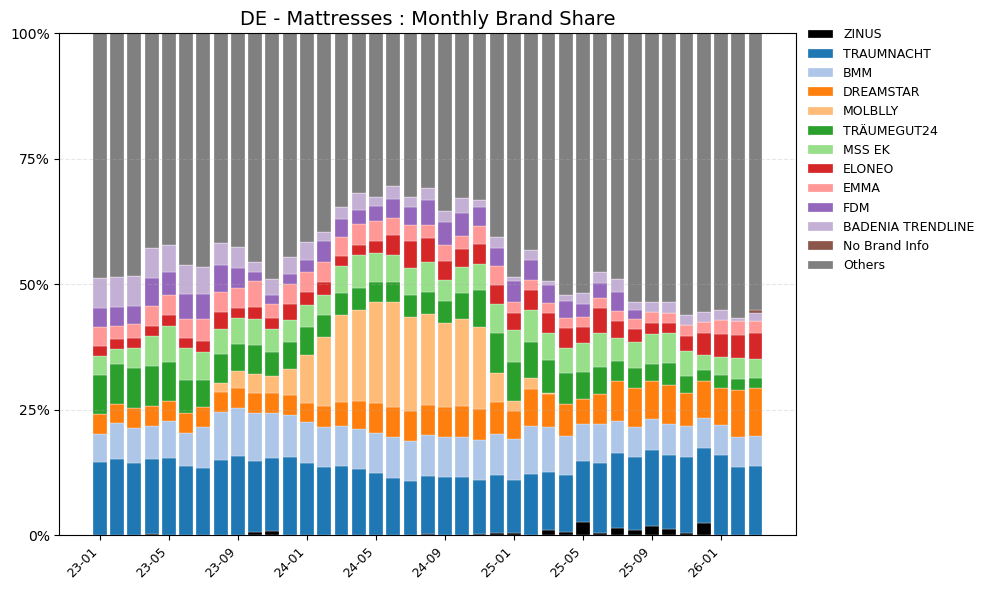

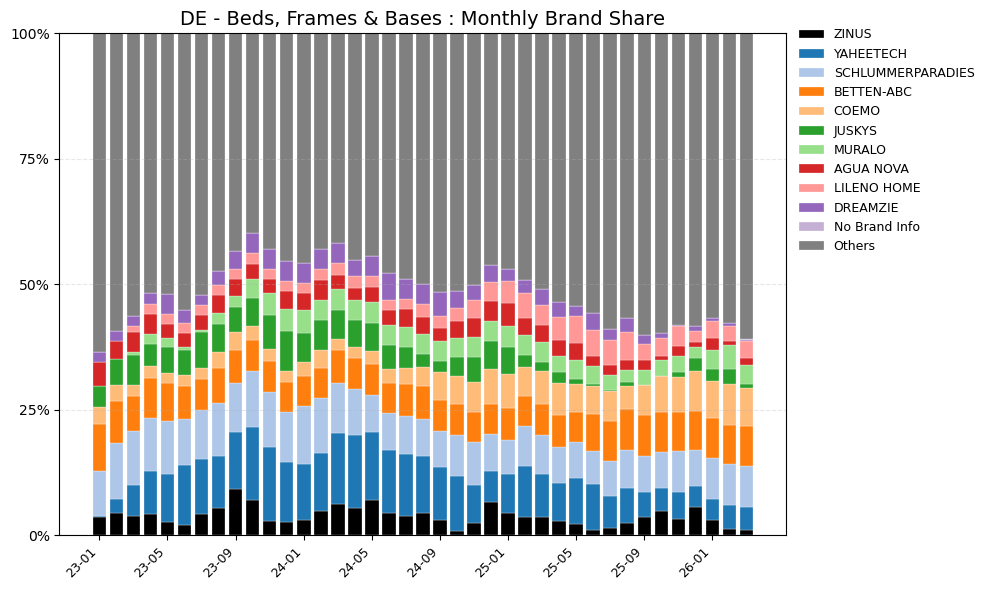

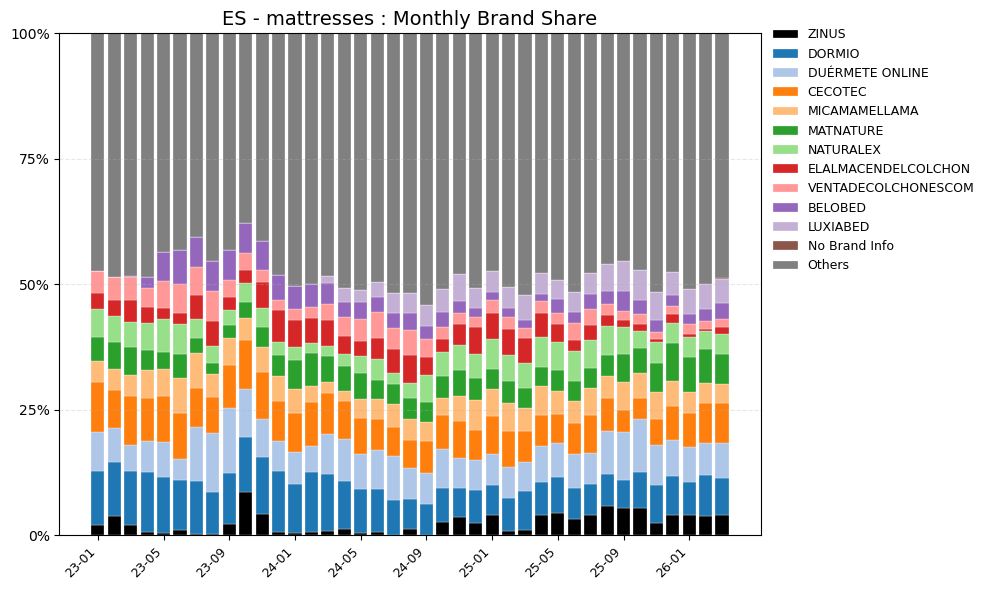

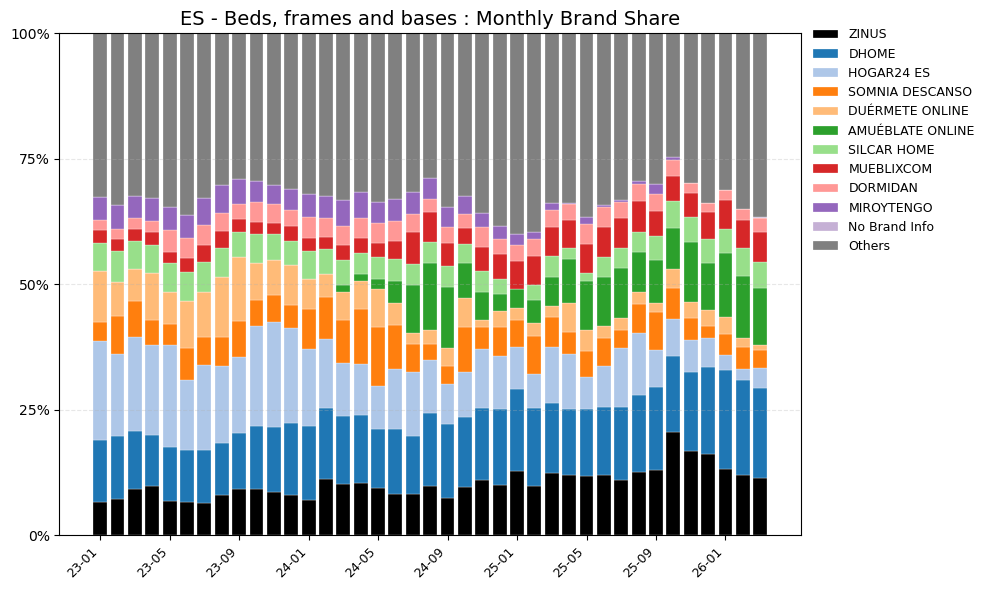

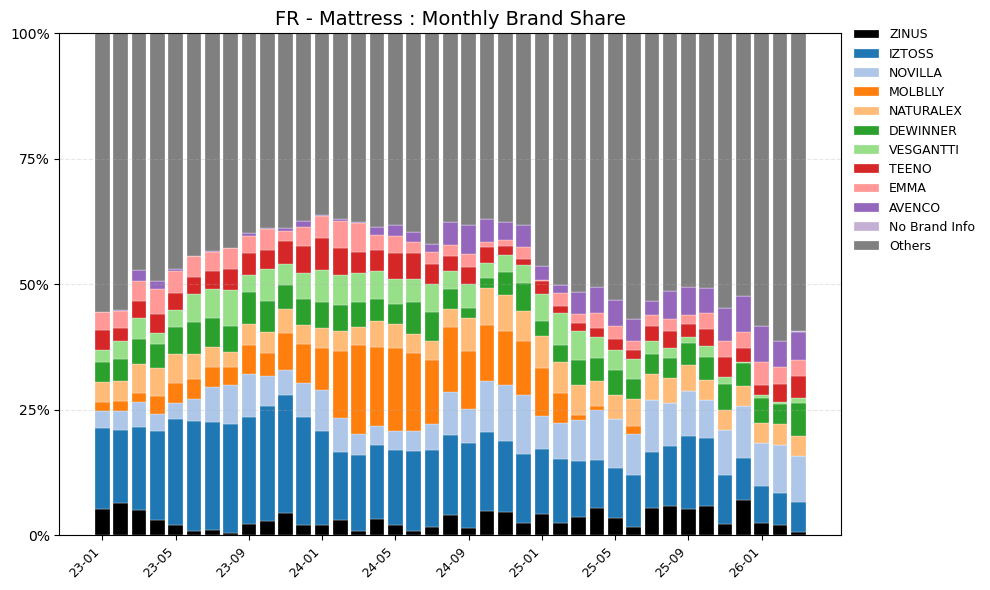

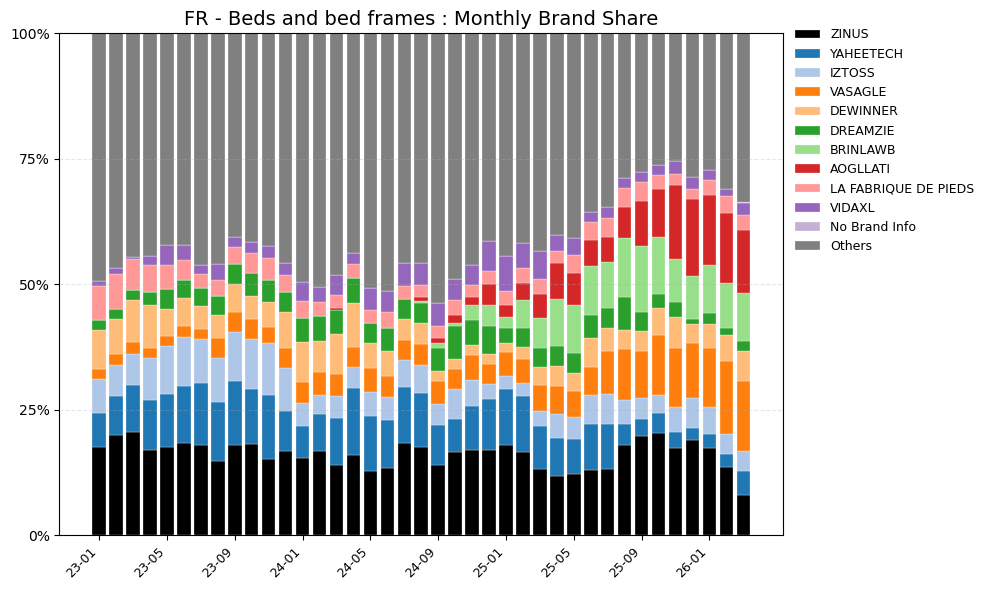

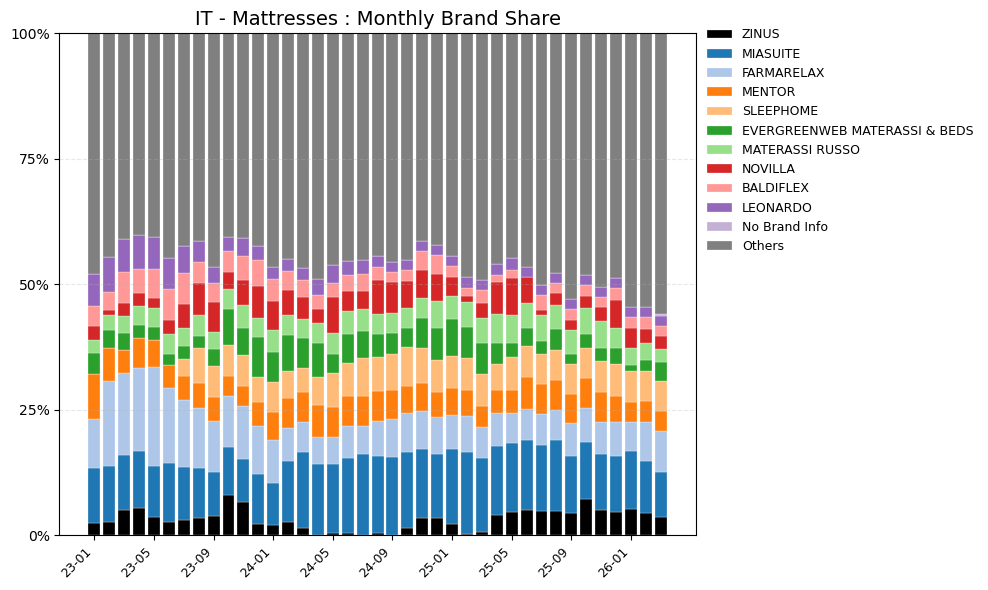

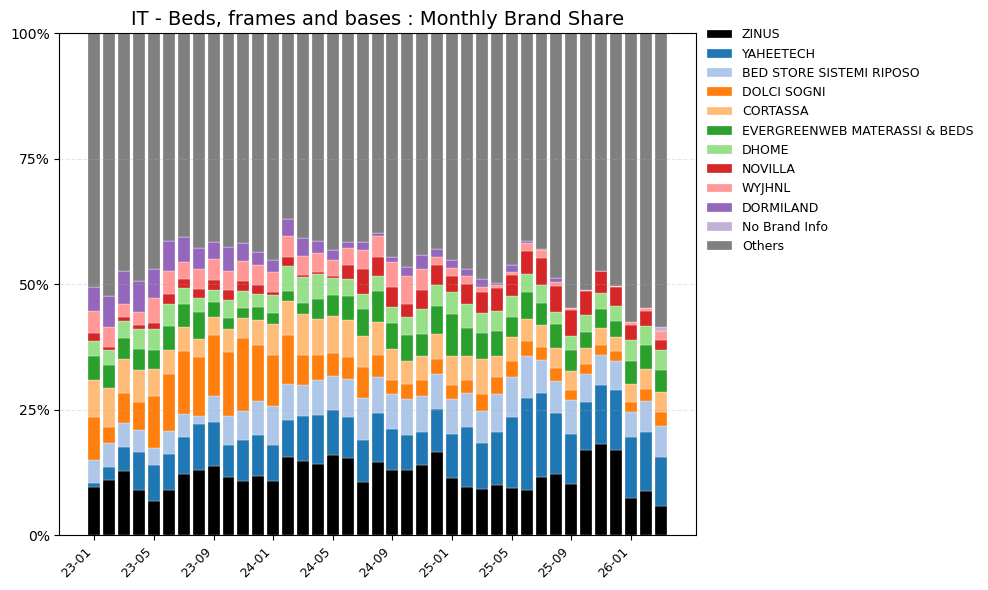

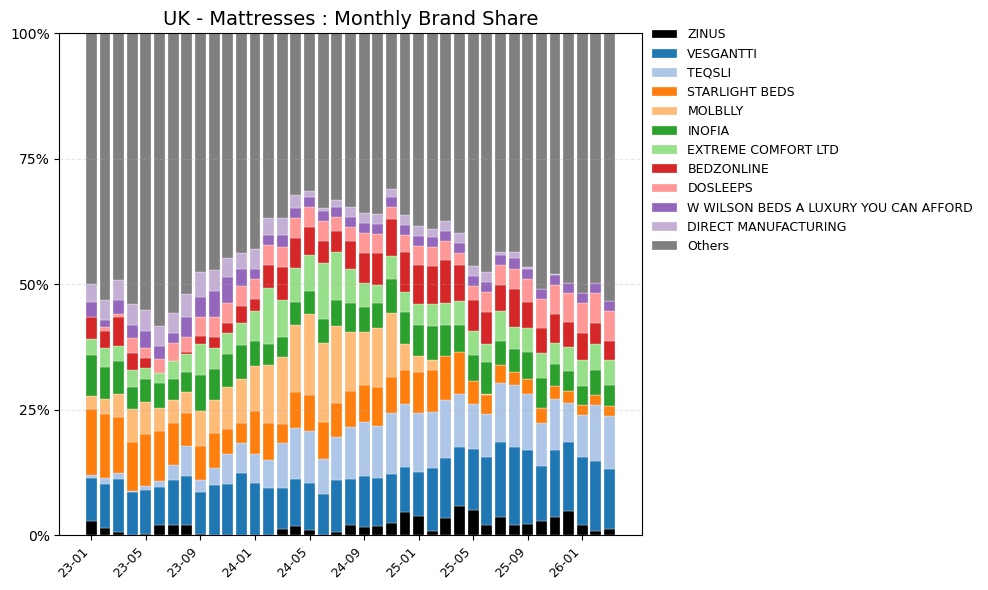

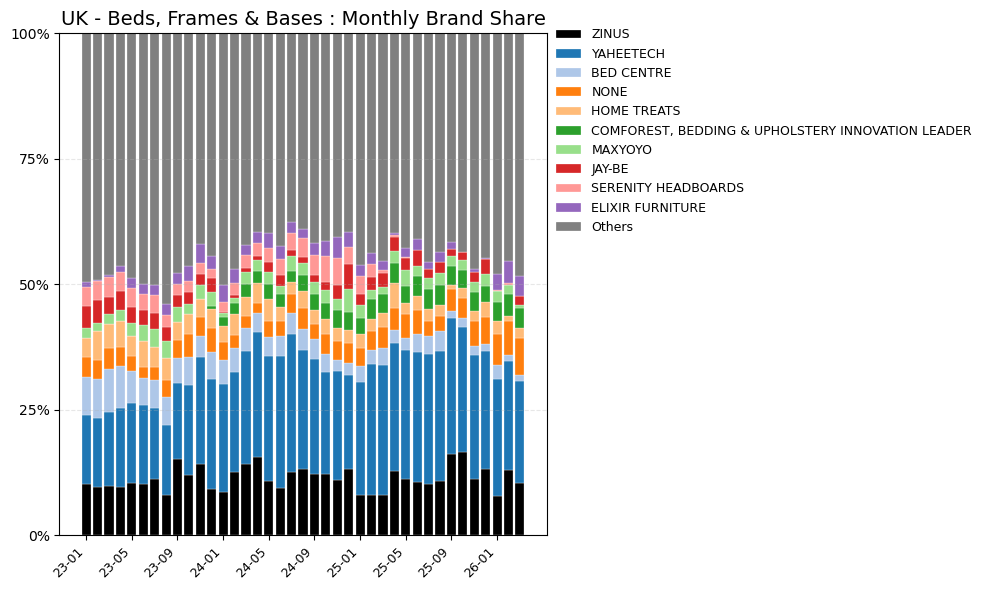

In [73]:

def parse_yrmonth(s: str):
    """'23-01' → (2023, 1) 숫자 튜플 (정렬용 키)"""
    m = re.search(r'(\d{2})-(\d{2})', str(s))
    if m:
        return (2000 + int(m.group(1)), int(m.group(2)))
    return (9999, 99)

def make_colors(n: int):
    """브랜드가 많을 경우 대비해서 색상 팔레트 확장"""
    cols = []
    for cm in (plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c):
        cols.extend([cm(i) for i in range(cm.N)])
    if n > len(cols):
        extra = n - len(cols)
        cols.extend([plt.cm.hsv(i / max(1, extra)) for i in range(extra)])
    return cols[:n]

def is_others(name):
    """'Others', 'OTHERS', 'others' 등 모두 True 반환"""
    return str(name).strip().upper() == 'OTHERS'

def is_zinus(name):
    """'Zinus', 'ZINUS', 'zinus' 등 모두 True 반환"""
    return str(name).strip().upper() == 'ZINUS'

# ---------- 파라미터 ----------
MAX_XTICKS = 12
FIGSIZE = (10, 6)

# ---------- 모든 국가 대상으로 개별 그래프 ----------
for country, df_c in df_mon.groupby('country', sort=True):
    if df_c.empty:
        continue

    cats = sorted(
        df_c['bsr_ctgry'].dropna().unique(),
        key=lambda c: (0 if ('mattress' in str(c).lower()) else 1, str(c).lower())
    )

    for cat in cats:
        g = df_c[df_c['bsr_ctgry'] == cat].copy()
        if g.empty:
            continue

        months = sorted(g['yr_month'].dropna().unique(), key=parse_yrmonth)
        if not months:
            continue

        pvt = (
            g.groupby(['yr_month', 'brand'])['brand_share']
             .sum()
             .unstack(fill_value=0.0)
             .reindex(months)
             .fillna(0.0)
        )

        # --- 컬럼 순서: ZINUS 맨 앞(맨 아래), 나머지 내림차순, OTHERS 맨 뒤(맨 위) ---
        cols = list(pvt.columns)
        
        # ✅ 대소문자 구분 없이 찾기
        zinus_col = next((c for c in cols if is_zinus(c)), None)
        others_col = next((c for c in cols if is_others(c)), None)
        
        rest = [c for c in cols if not is_zinus(c) and not is_others(c)]
        rest_sorted = pvt[rest].sum(axis=0).sort_values(ascending=False).index.tolist()
        
        # ZINUS → 나머지 → OTHERS 순서
        ordered_cols = []
        if zinus_col: ordered_cols.append(zinus_col)
        ordered_cols.extend(rest_sorted)
        if others_col: ordered_cols.append(others_col)
        
        pvt = pvt.reindex(columns=ordered_cols)

        # --- 색상 매핑 ---
        cmap = {}
        if zinus_col: cmap[zinus_col] = 'black'
        if others_col: cmap[others_col] = 'gray'  # ✅ 회색
        
        rest_for_colors = [c for c in ordered_cols if not is_zinus(c) and not is_others(c)]
        color_list = make_colors(len(rest_for_colors))
        for j, br in enumerate(rest_for_colors):
            cmap[br] = color_list[j]

        # --- 개별 Figure로 그리기 ---
        fig, ax = plt.subplots(figsize=FIGSIZE)
        x = np.arange(len(months))
        bottom = np.zeros(len(months), dtype=float)

        for col in pvt.columns:
            ax.bar(
                x, pvt[col].values,
                bottom=bottom,
                label=col,
                color=cmap.get(col, None),
                edgecolor='white', linewidth=0.2
            )
            bottom += pvt[col].values

        ax.set_ylim(0, 1.0)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'])
        ax.set_title(f"{country} - {cat} : Monthly Brand Share", fontsize=14)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        n = len(months)
        step = max(1, int(np.ceil(n / MAX_XTICKS)))
        tick_idx = np.arange(0, n, step)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([months[i] for i in tick_idx], rotation=45, ha='right', fontsize=9)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(), by_label.keys(),
            loc='upper left', bbox_to_anchor=(1.01, 1.02),
            borderaxespad=0., fontsize=9, frameon=False,
            ncol=1 if len(by_label) < 20 else 2
        )

        plt.tight_layout()
        plt.show()

## 9. 기타

### - 월별 BSR Share 

In [63]:
df1 = df.copy()
df1['brand'] = df1['brand'].astype(str).str.upper()

# === 1) 대상 국가/카테고리 필터 ===
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"],
}
mask_list = [
    (df1['country'] == c) & (df1['bsr_ctgry'].isin(cats))
    for c, cats in allowed_pairs.items()
]

df2 = df1[np.logical_or.reduce(mask_list)].copy()
# NO BRAND INFO --> OTHERS
df2['brand'] = df2['brand'].replace('NO BRAND INFO', 'OTHERS')

print(df2)

        country               bsr_ctgry        asin  rank    bsr_date  \
0            ES              mattresses  B0CMQYC3TR    41  2024-11-08   
1            ES              mattresses  B0CLLTX4DL    48  2024-08-02   
3            DE              Mattresses  B01N5QV0CA     5  2024-09-12   
4            DE              Mattresses  B01NAQ1DL1    22  2023-02-15   
5            ES              mattresses  B07CWV5QTV    41  2025-04-15   
...         ...                     ...         ...   ...         ...   
1577584      ES  Beds, frames and bases  B0CB6W36CN    28  2024-09-27   
1577585      ES  Beds, frames and bases  B00T9Y8TQA    45  2023-02-02   
1577586      ES  Beds, frames and bases  B0CQKV3BPX    18  2025-04-04   
1577587      ES  Beds, frames and bases  B07MTB8TRX    48  2025-03-16   
1577588      ES  Beds, frames and bases  B07YLHWVWD    32  2025-05-03   

                     brand                           brand_raw  \
0          DUÉRMETE ONLINE                     DUÉRMETE O

In [92]:
# === 2) 주차별 전체/브랜드별 카운트 ===
tot = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_month'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_month', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_mo = by_brand.merge(tot, on=['country','bsr_ctgry','yr_month'], how='left')
df_mo['brand_share_monthly'] = df_mo['brand_count'] / df_mo['total_count']

print(df_mo)

     country             bsr_ctgry yr_month           brand  brand_count  \
0         DE  Beds, Frames & Bases    23-01       AGUA NOVA           66   
1         DE  Beds, Frames & Bases    23-01      BETTEN-ABC          131   
2         DE  Beds, Frames & Bases    23-01           COEMO           47   
3         DE  Beds, Frames & Bases    23-01        DREAMZIE           28   
4         DE  Beds, Frames & Bases    23-01          JUSKYS           59   
...      ...                   ...      ...             ...          ...   
3699      UK            Mattresses    25-10          OTHERS           85   
3700      UK            Mattresses    25-10  STARLIGHT BEDS            6   
3701      UK            Mattresses    25-10          TEQSLI           14   
3702      UK            Mattresses    25-10       VESGANTTI           12   
3703      UK            Mattresses    25-10           ZINUS            6   

      total_count  brand_share_monthly  
0            1400             0.047143  
1    

In [94]:
df_uk = df_mo[df_mo['country']=='UK']

In [96]:
df_uk['bsr_ctgry'].unique()

array(['Beds, Frames & Bases', 'Mattresses'], dtype=object)

In [98]:
df_uk_matt = df_uk[df_uk['bsr_ctgry']=='Mattresses']

In [100]:
print(df_uk_matt)

     country   bsr_ctgry yr_month                 brand  brand_count  \
3318      UK  Mattresses    23-01            BEDZONLINE           60   
3319      UK  Mattresses    23-01  DIRECT MANUFACTURING           50   
3320      UK  Mattresses    23-01              DOSLEEPS            2   
3321      UK  Mattresses    23-01   EXTREME COMFORT LTD           44   
3322      UK  Mattresses    23-01             GOOD NITE           59   
...      ...         ...      ...                   ...          ...   
3699      UK  Mattresses    25-10                OTHERS           85   
3700      UK  Mattresses    25-10        STARLIGHT BEDS            6   
3701      UK  Mattresses    25-10                TEQSLI           14   
3702      UK  Mattresses    25-10             VESGANTTI           12   
3703      UK  Mattresses    25-10                 ZINUS            6   

      total_count  brand_share_monthly  
3318         1399             0.042888  
3319         1399             0.035740  
3320        

In [102]:
df_uk_matt.to_csv('uk_mattress_monthly_topbrand_1014.csv', index=False)

### - 년도별 UK Beds

In [51]:
df1 = df.copy()

In [53]:
df_uk_beds = df1[(df1['country']=='UK') &
                (df1['bsr_ctgry']=='Beds, Frames & Bases')].copy()

In [55]:
df_uk_beds['year'] = df_uk_beds['yr_month'].str[:2].astype(int)+2000

In [57]:
df_uk_beds['brand'] = df_uk_beds['brand'].astype(str).str.upper()
df_uk_beds['brand'] = df_uk_beds['brand'].fillna('OTHERS')

In [59]:
print(df_uk_beds)

        country             bsr_ctgry        asin  rank    bsr_date  \
360411       UK  Beds, Frames & Bases  B07N7TTM57    34  2024-02-12   
360415       UK  Beds, Frames & Bases  B0DVLMQZQD    24  2025-03-08   
360416       UK  Beds, Frames & Bases  B07ZJKJ6VP    25  2024-09-28   
360419       UK  Beds, Frames & Bases  B0C4BB7S9R    50  2024-01-20   
360420       UK  Beds, Frames & Bases  B0BJ1MN5K9     6  2024-04-21   
...         ...                   ...         ...   ...         ...   
2907766      UK  Beds, Frames & Bases  B0B2S67QNX    18  2024-09-11   
2907767      UK  Beds, Frames & Bases  B0CNBXHZTK    32  2024-10-30   
2907768      UK  Beds, Frames & Bases  B07BBR14NY    26  2024-03-21   
2907770      UK  Beds, Frames & Bases  B093C5NYY1     7  2023-11-03   
2907771      UK  Beds, Frames & Bases  B088X2RXS1    40  2023-03-20   

                    brand         brand_raw  \
360411             OTHERS       HUSSEINBOLT   
360415             OTHERS              HB-1   
360416

In [63]:
# === 2) 년도별 전체/브랜드별 카운트 ===
tot = (
    df_uk_beds.groupby(['country', 'bsr_ctgry', 'year'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df_uk_beds.groupby(['country', 'bsr_ctgry', 'year', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_yr = by_brand.merge(tot, on=['country','bsr_ctgry','year'], how='left')
df_yr['brand_share'] = df_yr['brand_count'] / df_yr['total_count']

print(df_yr)


   country             bsr_ctgry  year                brand  brand_count  \
0       UK  Beds, Frames & Bases  2023           BED CENTRE         1150   
1       UK  Beds, Frames & Bases  2023            BELLEDORM          432   
2       UK  Beds, Frames & Bases  2023     ELIXIR FURNITURE          343   
3       UK  Beds, Frames & Bases  2023              GENERIC          680   
4       UK  Beds, Frames & Bases  2023          HOME TREATS          788   
5       UK  Beds, Frames & Bases  2023               JAY-BE          572   
6       UK  Beds, Frames & Bases  2023              MAXYOYO          474   
7       UK  Beds, Frames & Bases  2023               OTHERS         8303   
8       UK  Beds, Frames & Bases  2023  SERENITY HEADBOARDS          558   
9       UK  Beds, Frames & Bases  2023            YAHEETECH         2946   
10      UK  Beds, Frames & Bases  2023                ZINUS         1981   
11      UK  Beds, Frames & Bases  2024           BED CENTRE          699   
12      UK  

In [65]:
df_yr.to_csv('df_uk_beds_year_1015.csv', index=False)

In [67]:
pivot = df_yr.pivot_table(
    index='brand',
    columns='year',
    values='brand_share',
    aggfunc='sum'  # 동일 brand-year 중복이 있다면 합산 (보통 1개라 그대로)
).fillna(0)
col_2025 = 2025 if 2025 in pivot.columns else '2025'
pivot = pivot.sort_values(by=col_2025, ascending=False)
# 확인
print(pivot)

year                     2023      2024      2025
brand                                            
OTHERS               0.455533  0.415646  0.432587
YAHEETECH            0.161628  0.229701  0.256394
ZINUS                0.108685  0.121164  0.106788
GENERIC              0.037307  0.040461  0.061363
BED CENTRE           0.063093  0.038375  0.029921
HOME TREATS          0.043233  0.032775  0.025212
JAY-BE               0.031382  0.016525  0.023473
MAXYOYO              0.026005  0.022564  0.022676
BELLEDORM            0.023701  0.021631  0.017388
ELIXIR FURNITURE     0.018818  0.027121  0.016446
SERENITY HEADBOARDS  0.030614  0.034038  0.007752
